In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [22]:
df=pd.read_csv("train.csv")
print(df.head())
print(df.dtypes)

   Index geohash  day timestamp    demand     RoadType  NumberofLanes  \
0      0  qp02z1   48       0:0  0.048804          NaN              1   
1      1  qp02zt   48       0:0  0.118507  Residential              3   
2      2  qp08bj   48       0:0  0.027132  Residential              1   
3      3  qp08gt   48       0:0  0.003272  Residential              1   
4      4  qp02zq   48       0:0  0.010819  Residential              1   

  LargeVehicles Landmarks  Temperature Weather  
0   Not Allowed        No          NaN     NaN  
1       Allowed       Yes    31.104565   Sunny  
2   Not Allowed        No    25.919267   Sunny  
3   Not Allowed        No          NaN   Rainy  
4   Not Allowed        No    10.803667   Rainy  
Index              int64
geohash           object
day                int64
timestamp         object
demand           float64
RoadType          object
NumberofLanes      int64
LargeVehicles     object
Landmarks         object
Temperature      float64
Weather          

In [23]:
#checking for null values
print(df.shape)
print(df.isnull().sum())
print(df.info())

(77299, 11)
Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage

<Axes: >

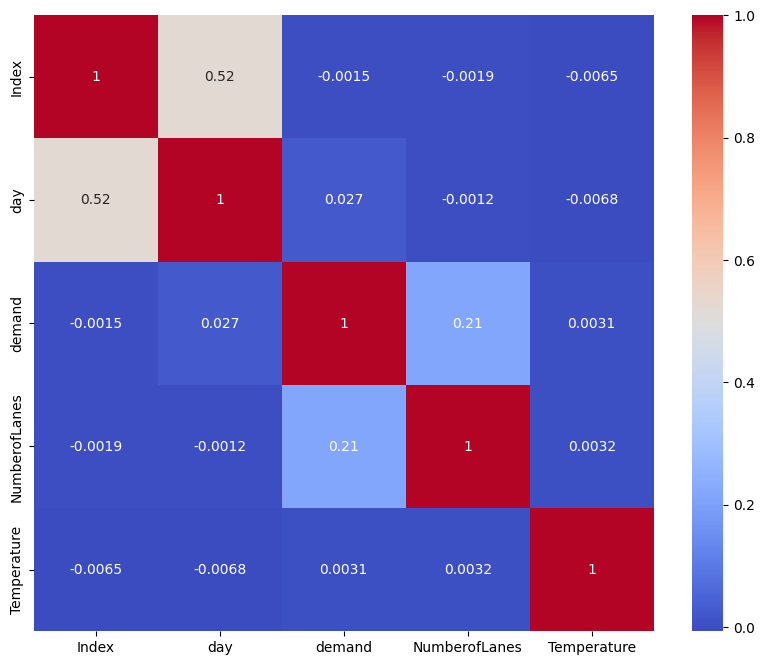

In [24]:
#finding correlation between the features
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(),annot=True,cmap="coolwarm")

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
[0 1]
0    0
1    0
2    0
3    0
4    0
Name: Landmarks, dtype: int64
[0 1]
0    0
1    0
2    0
3    0
4    0
Name: LargeVehicles, dtype: int64
[0.09721813 0.0942472  0.09447081 0.09337152 0.09258097]
Weather
0.094247    27717
0.094471    20824
0.093372    20243
0.092581     7718
0.097218      797
Name: count, dtype: int64
5
4


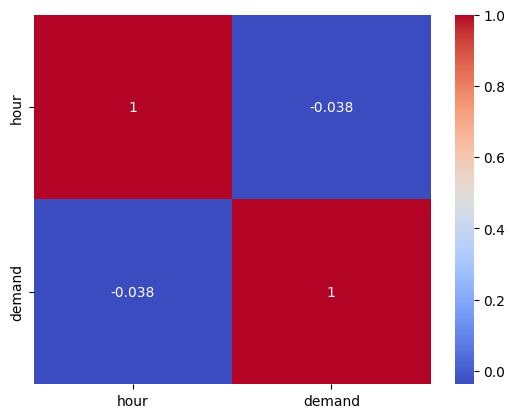

In [34]:
#Analyzing the three object features
df["RoadType"].unique()
#filling nan values with the other type of road
df["RoadType"]=df["RoadType"].fillna("Other")

#Analyzing the timestamp feature
df["timestamp"]=pd.to_datetime(df["timestamp"],format="%H:%M")
df["hour"]=df["timestamp"].dt.hour
print(df["hour"].unique())
#finding correlation between hour and demand
sns.heatmap(df[["hour","demand"]].corr(),annot=True,cmap="coolwarm")

#Converting landmarks into binary features
#0 for No and 1 for Yes
print(df["Landmarks"].unique())
df["Landmarks"]=(df["Landmarks"]=="Yes").astype(int)

print(df["Landmarks"].head())
#Converting largevehicles into binary features
print(df["LargeVehicles"].unique())
df["LargeVehicles"]=(df["LargeVehicles"]=="Allowed").astype(int)
print(df["LargeVehicles"].head())


#unique weathers

df["Weather"]=df["Weather"].fillna("Others")
print(df["Weather"].unique())

print(df["Weather"].value_counts())
from category_encoders import TargetEncoder
encoder = TargetEncoder()
df["Weather"] = encoder.fit_transform(df["Weather"], df["demand"])
print(len(df["Weather"].unique()))#Number of unique values in geohash feature after target encoding is same

df["RoadType"]=encoder.fit_transform(df["RoadType"], df["demand"])
print(len(df["RoadType"].unique()))#Number of unique values in geohash feature after target encoding is same



In [26]:
#using geohash to get lat and long from geohash
import pygeohash as pgh

def decode_geohash(g):
    lat, lon = pgh.decode(g)
    return pd.Series([lat, lon])

df[['lat', 'lon']] = df['geohash'].apply(decode_geohash)



In [27]:
df.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,lat,lon
0,0,qp02z1,48,1900-01-01,0.048804,Other,1,0,0,NaN,0.097218,0,-5.484924,90.664673
1,1,qp02zt,48,1900-01-01,0.118507,Residential,3,1,1,31.104565,0.094247,0,-5.462952,90.686646
2,2,qp08bj,48,1900-01-01,0.027132,Residential,1,0,0,25.919267,0.094247,0,-5.462952,90.708618
3,3,qp08gt,48,1900-01-01,0.003272,Residential,1,0,0,NaN,0.094471,0,-5.462952,90.862427
4,4,qp02zq,48,1900-01-01,0.010819,Residential,1,0,0,10.803667,0.094471,0,-5.457458,90.675659


Number of unique values in geohash feature: 1249
1249


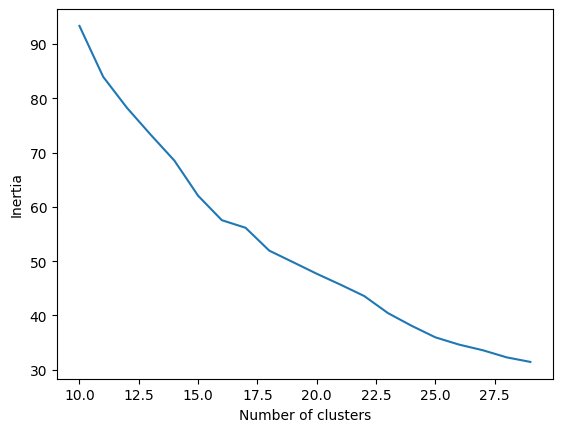

In [28]:
#printing unique values of geohash
print("Number of unique values in geohash feature:",len(df["geohash"].unique()))
#target encoding for geohash feature
df["geohash"] = df["geohash"].astype(str)
from category_encoders import TargetEncoder
from sklearn.metrics import silhouette_score
encoder = TargetEncoder()
df["geohash"] = encoder.fit_transform(df["geohash"], df["demand"])
print(len(df["geohash"].unique()))#Number of unique values in geohash feature after target encoding is same

#performing k means clustering on lat and long features to get location clusters
from sklearn.cluster import KMeans
#finding best c=number of clusters using elbow method
points=[]

for k in range(10,30):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df[["lat", "lon"]])
    points.append(kmeans.inertia_)

plt.plot(range(10,30), points)
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")


kmeans = KMeans(
    n_clusters=21,
    random_state=42,
    n_init=10
)

df['geo_cluster'] = kmeans.fit_predict(
    df[['lat', 'lon']]
)

<Figure size 100x100 with 0 Axes>

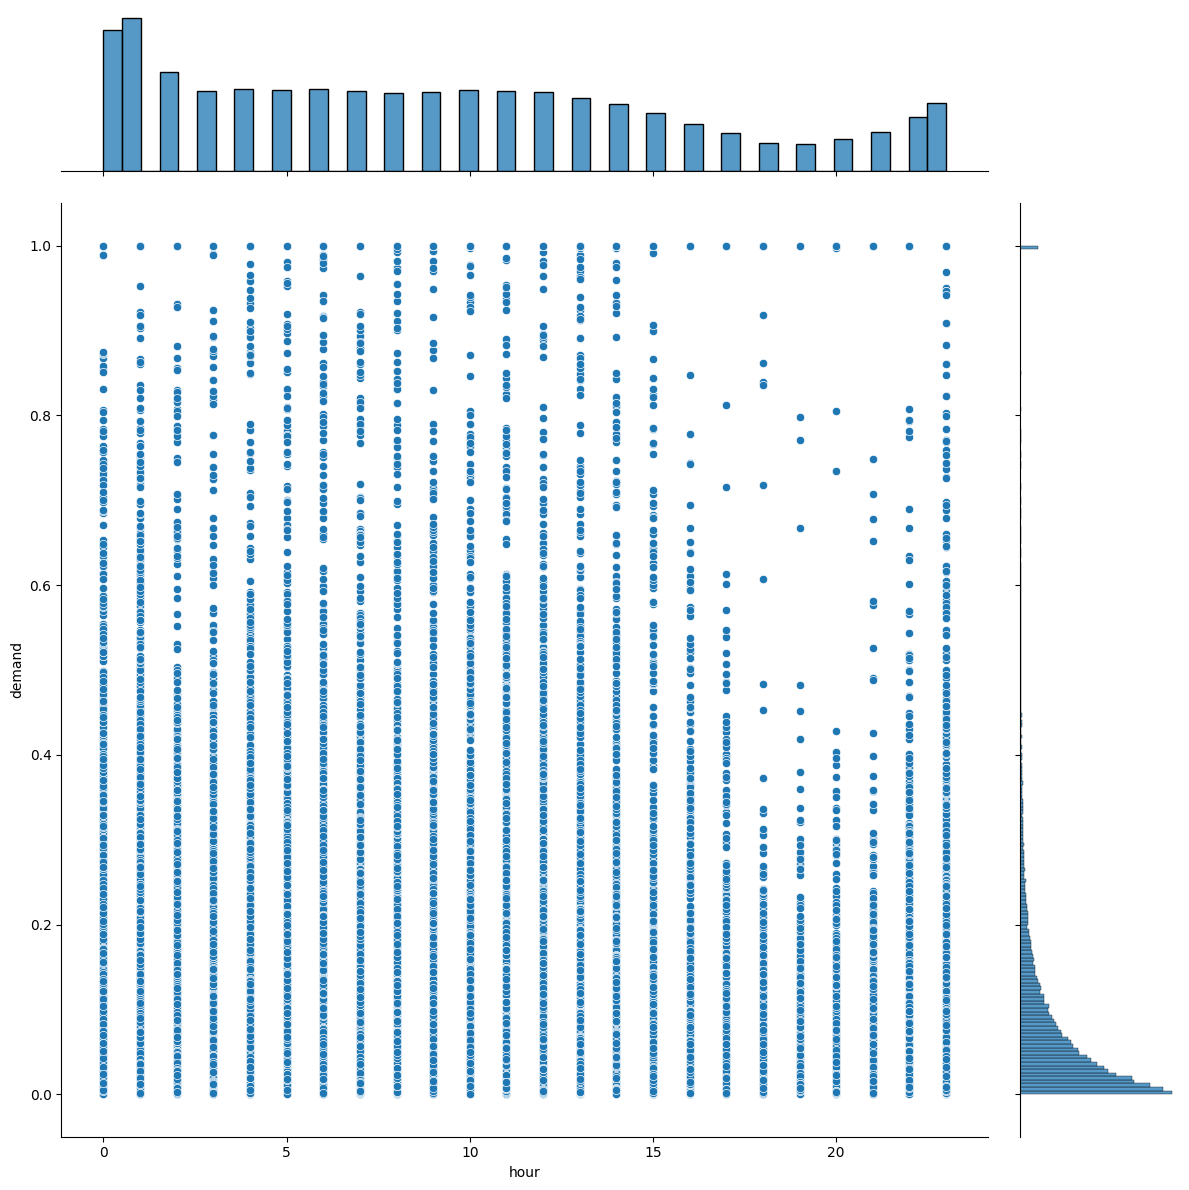

In [29]:
plt.figure(figsize=(1,1))
sns.jointplot(data=df,x="hour",y="demand", height = 12)
#hence we can dividethe hours into 4 categories(0:Night,1:Morning,2:Afternoon,3:Evening)
def hour_category(hour):
    if 0 <= hour < 6:
        return 0
    elif 6 <= hour < 12:
        return 1
    elif 12 <= hour < 18:
        return 2
    else:
        return 3
df["phase_of_day"]=df["hour"].apply(hour_category)


<Axes: xlabel='phase_of_day', ylabel='demand'>

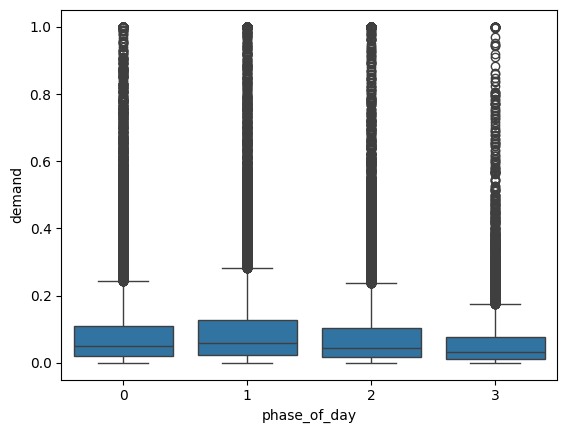

In [30]:
plt.Figure(figsize=(10,8))
sns.boxplot(data=df,x="phase_of_day",y="demand")
#Mostly morning visits and evening has least visit demands


[48 49]
day
48    69427
49     7872
Name: count, dtype: int64


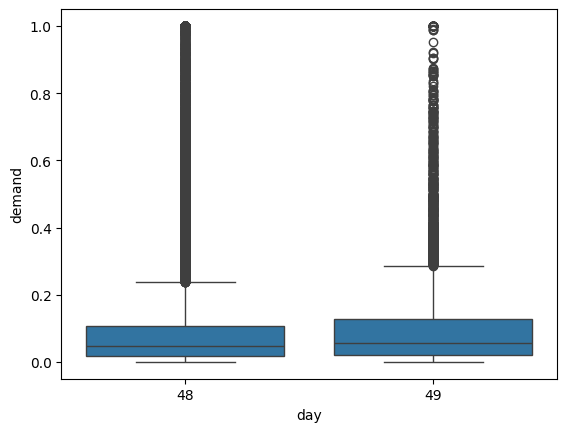

In [31]:
#Number of days available
print(df["day"].unique())
sns.boxplot(data=df,x="day",y="demand")
print(df["day"].value_counts())
#hence they can be classified into 2 categories weekday,weekend

In [36]:

#Filling temperatures with mean values according to the phase of the day
for phase in df["phase_of_day"].unique():
    mean_temp=df[df["phase_of_day"]==phase]["Temperature"].mean() #mean temperature in that phase of the day
    df.loc[df["phase_of_day"]==phase,"Temperature"]=df.loc[df["phase_of_day"]==phase,"Temperature"].fillna(mean_temp)



In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Index          77299 non-null  int64         
 1   geohash        77299 non-null  float64       
 2   day            77299 non-null  int64         
 3   timestamp      77299 non-null  datetime64[ns]
 4   demand         77299 non-null  float64       
 5   RoadType       77299 non-null  float64       
 6   NumberofLanes  77299 non-null  int64         
 7   LargeVehicles  77299 non-null  int64         
 8   Landmarks      77299 non-null  int64         
 9   Temperature    77299 non-null  float64       
 10  Weather        77299 non-null  float64       
 11  hour           77299 non-null  int32         
 12  lat            77299 non-null  float64       
 13  lon            77299 non-null  float64       
 14  geo_cluster    77299 non-null  int32         
 15  phase_of_day   7729

In [ ]:
#USING XGBOOST REGRESSOR WITH ALL THE FEATURES
#USING RANDOMIZEDSEARCHCV TO FIND BEST HYPERPARAMETERS
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

#train-test-split
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=["demand","timestamp"]),df["demand"],test_size=0.2,random_state=42)
x_val,x_test,y_val,y_test=train_test_split(x_test,y_test,test_size=0.5,random_state=42)

RANDOM_STATE = 42
def perform_tuning(x_train,y_train):
    # Base Model
base_xgb = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Hyperparameter Search
random_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_grid,
    n_iter=50,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search.fit(x_train, y_train)

best_model = random_search.best_estimator_

print("Best Parameters:")
print(random_search.best_params_)

print("Best CV RMSE:")
print(-random_search.best_score_)

return best_model

# Hyperparameter Grid
param_grid = {
    'n_estimators': [200, 300, 500, 700, 1000],
    'max_depth': [3, 5, 7, 9, 12],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 3, 5, 10]
}

# Hyperparameter Search
random_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_grid,
    n_iter=50,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search.fit(x_train, y_train)

best_model = random_search.best_estimator_

print("Best Parameters:")
print(random_search.best_params_)

print("Best CV RMSE:")
print(-random_search.best_score_)




Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters:
{'subsample': 0.6, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.8}
Best CV RMSE:
0.030854755161527452


<Figure size 1000x800 with 0 Axes>

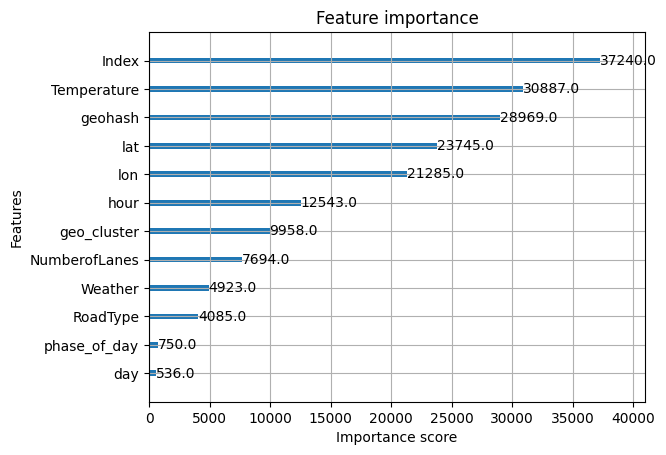

In [39]:
#checking feature importance 
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plot_importance(best_model,
                max_num_features=20)
plt.show()

In [42]:
#dropping some features and checking feature importance again
x_train_new=x_train.drop(columns=["Index","geohash"])
x_val_new=x_val.drop(columns=["Index","geohash"])
x_test_new=x_test.drop(columns=["Index","geohash"])
#USING XGBOOST REGRESSOR WITH ALL THE FEATURES
#USING RANDOMIZEDSEARCHCV TO FIND BEST HYPERPARAMETERS
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

#train-test-split
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=["demand","timestamp"]),df["demand"],test_size=0.2,random_state=42)
x_val,x_test,y_val,y_test=train_test_split(x_test,y_test,test_size=0.5,random_state=42)

RANDOM_STATE = 42

# Base Model
base_xgb = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Hyperparameter Grid
param_grid = {
    'n_estimators': [200, 300, 500, 700, 1000],
    'max_depth': [3, 5, 7, 9, 12],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 3, 5, 10]
}

# Hyperparameter Search
random_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_grid,
    n_iter=50,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search.fit(x_train, y_train)

best_model = random_search.best_estimator_

print("Best Parameters:")
print(random_search.best_params_)

print("Best CV RMSE:")
print(-random_search.best_score_)




Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters:
{'subsample': 0.6, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.8}
Best CV RMSE:
0.030854755161527452
